In [3]:
from google.colab import files

uploaded = files.upload()

Saving sinh_vien.csv to sinh_vien.csv


In [4]:
#Bài 1

import pandas as pd
df = pd.read_csv("sinh_vien.csv")

#Nhóm sinh viên có điểm giữa kỳ từ 7 trở lên
nhom_diem_cao = df[df["diem_giua_ky"] >= 7]

#Nhóm sinh viên có điểm giữa kỳ dưới 7
nhom_con_lai = df[df["diem_giua_ky"] < 7]

#Tính các kết quả cần in
so_ban_diem_cao = len(nhom_diem_cao)
ty_le_qua_diem_cao = nhom_diem_cao["qua_mon"].mean()
ty_le_qua_nhom_con_lai = nhom_con_lai["qua_mon"].mean()

print("So sinh vien co diem giua ky tu 7 tro len:", so_ban_diem_cao)
print(f"Ty le qua mon cua nhom diem >= 7: {ty_le_qua_diem_cao:.4f}")
print(f"Ty le qua mon cua nhom diem < 7: {ty_le_qua_nhom_con_lai:.4f}")

print()
print("Nhan xet:")
if ty_le_qua_diem_cao > ty_le_qua_nhom_con_lai:
    print("Diem giua ky co kha nang phan biet hai nhom,")
    print("vi nhom co diem giua ky tu 7 tro len co ty le qua mon cao hon.")
else:
    print("Diem giua ky khong phan biet ro hai nhom")
    print("theo ty le qua mon trong bo du lieu.")

So sinh vien co diem giua ky tu 7 tro len: 31
Ty le qua mon cua nhom diem >= 7: 0.9032
Ty le qua mon cua nhom diem < 7: 0.4831

Nhan xet:
Diem giua ky co kha nang phan biet hai nhom,
vi nhom co diem giua ky tu 7 tro len co ty le qua mon cao hon.


Nhóm sinh viên có điểm giữa kỳ từ 7 trở lên có tỷ lệ qua môn cao hơn nhóm còn lại, cho thấy điểm giữa kỳ có khả năng phân biệt hai nhóm trong bộ dữ liệu.

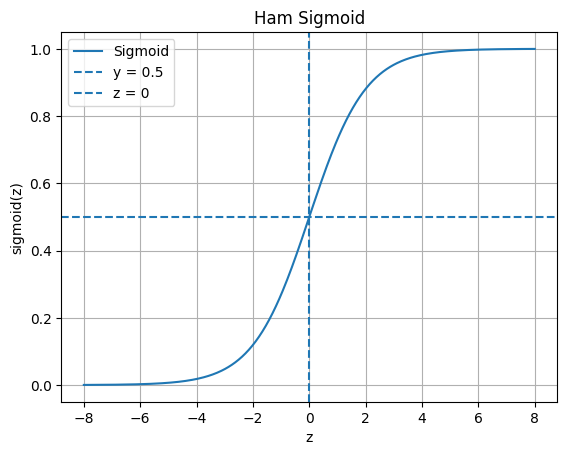

Da luu do thi thanh sigmoid.png


In [5]:
#Bài 2

import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

#Tạo các giá trị z từ -8 đến 8
z = np.linspace(-8, 8, 400)

#Tính giá trị sigmoid
y = sigmoid(z)

#Vẽ đồ thị
plt.plot(z, y, label="Sigmoid")
plt.axhline(0.5, linestyle="--", label="y = 0.5")
plt.axvline(0, linestyle="--", label="z = 0")

plt.xlabel("z")
plt.ylabel("sigmoid(z)")
plt.title("Ham Sigmoid")
plt.grid(True)
plt.legend()

#Lưu hình
plt.savefig("sigmoid.png", dpi=300, bbox_inches="tight")

#Hiển thị
plt.show()

print("Da luu do thi thanh sigmoid.png")

In [6]:
#Bài 3

import pandas as pd
from sklearn.linear_model import LogisticRegression

#Đọc dữ liệu
df = pd.read_csv("sinh_vien.csv")

#X và y
X = df[["gio_on"]]
y = df["qua_mon"]

#Khớp mô hình
mo_hinh = LogisticRegression()
mo_hinh.fit(X, y)

#Lấy hệ số w và b
w = float(mo_hinh.coef_[0][0])
b = float(mo_hinh.intercept_[0])

def du_doan(gio):
    #Tính z = w*x + b
    z = w * gio + b

    #Tính xác suất qua môn bằng sigmoid
    xac_suat = 1 / (1 + __import__("math").exp(-z))

    #Áp dụng ngưỡng 0.5
    nhan = 1 if xac_suat >= 0.5 else 0

    print(f"So gio on: {gio:.2f}")
    print(f"z = {z:.4f}")
    print(f"Xac suat qua mon = {xac_suat:.4f}")
    print(f"Nhãn = {nhan}")
    print()

print(f"w = {w:.6f}")
print(f"b = {b:.6f}")
print()

du_doan(3)
du_doan(8)
du_doan(12.89)
du_doan(18)
du_doan(26)

w = 0.392819
b = -5.064890

So gio on: 3.00
z = -3.8864
Xac suat qua mon = 0.0201
Nhãn = 0

So gio on: 8.00
z = -1.9223
Xac suat qua mon = 0.1276
Nhãn = 0

So gio on: 12.89
z = -0.0015
Xac suat qua mon = 0.4996
Nhãn = 0

So gio on: 18.00
z = 2.0059
Xac suat qua mon = 0.8814
Nhãn = 1

So gio on: 26.00
z = 5.1484
Xac suat qua mon = 0.9942
Nhãn = 1



Khi số giờ ôn khoảng 12.89 giờ, giá trị z = w × x + b gần bằng 0. Theo hàm sigmoid, khi z = 0 thì xác suất bằng đúng 0.5. Vì vậy tại 12.89 giờ, mô hình gần như phân vân giữa hai nhãn qua môn và rớt môn.

In [7]:

#Bài 4

import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

#Đọc dữ liệu
df = pd.read_csv("sinh_vien.csv")

X = df[["gio_on"]]
y = df["qua_mon"]

#Chia dữ liệu giống tài liệu
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=17,
    stratify=y
)

#Huấn luyện
mo_hinh = LogisticRegression()
mo_hinh.fit(X_train, y_train)

#Dự đoán
y_pred = mo_hinh.predict(X_test)

#Lấy TP, TN, FP, FN
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print("Bon gia tri tu ma tran nham lan:")
print(f"TN = {tn}")
print(f"FP = {fp}")
print(f"FN = {fn}")
print(f"TP = {tp}")
print()

#Tổng số mẫu kiểm tra
n = len(y_test)

#Tự tính Accuracy
accuracy = (tp + tn) / n

#Tự tính Precision
precision = tp / (tp + fp)

#Tự tính Recall
recall = tp / (tp + fn)

#Tự tính F1
f1 = 2 * precision * recall / (precision + recall)

print("Ket qua tu tinh:")
print(f"Accuracy  = {accuracy:.4f}")
print(f"Precision = {precision:.4f}")
print(f"Recall    = {recall:.4f}")
print(f"F1        = {f1:.4f}")

Bon gia tri tu ma tran nham lan:
TN = 9
FP = 3
FN = 1
TP = 17

Ket qua tu tinh:
Accuracy  = 0.8667
Precision = 0.8500
Recall    = 0.9444
F1        = 0.8947


Accuracy là tỷ lệ số dự đoán đúng trên tổng số mẫu dữ liệu. Precision cho biết trong các mẫu được mô hình dự đoán là qua môn, có bao nhiêu mẫu thực sự qua môn. Recall cho biết trong các mẫu thực sự qua môn, mô hình đã dự đoán đúng được bao nhiêu mẫu. F1 là chỉ số kết hợp giữa Precision và Recall, giúp đánh giá đồng thời khả năng dự đoán đúng và khả năng tìm ra các mẫu thực sự qua môn của mô hình.

In [8]:
#Bài 5

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

#Đọc dữ liệu
df = pd.read_csv("sinh_vien.csv")

X = df[["gio_on"]]
y = df["qua_mon"]

#Chia dữ liệu giống tài liệu
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=17,
    stratify=y
)

#Huấn luyện mô hình
mo_hinh = LogisticRegression()
mo_hinh.fit(X_train, y_train)

#Lấy xác suất qua môn
p = mo_hinh.predict_proba(X_test)[:, 1]

#Lưu kết quả
ket_qua = []

print("Nguong    F1")

for nguong in np.arange(0.05, 1.0, 0.05):
    y_pred = (p >= nguong).astype(int)

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    ket_qua.append((nguong, f1))

    print(f"{nguong:.2f}     {f1:.4f}")

#Tìm F1 cao nhất
nguong_tot_nhat, f1_cao_nhat = max(
    ket_qua,
    key=lambda x: x[1]
)

print()
print(f"Nguong co F1 cao nhat: {nguong_tot_nhat:.2f}")
print(f"F1 cao nhat: {f1_cao_nhat:.4f}")

Nguong    F1
0.05     0.7826
0.10     0.8182
0.15     0.8182
0.20     0.8571
0.25     0.9000
0.30     0.8947
0.35     0.8947
0.40     0.8947
0.45     0.8947
0.50     0.8947
0.55     0.8889
0.60     0.9412
0.65     0.9412
0.70     0.9091
0.75     0.8750
0.80     0.8387
0.85     0.8000
0.90     0.5600
0.95     0.4348

Nguong co F1 cao nhat: 0.60
F1 cao nhat: 0.9412


Khi thay đổi ngưỡng dự đoán từ 0.05 đến 0.95, giá trị F1 thay đổi theo từng ngưỡng. Ngưỡng có giá trị F1 cao nhất là ngưỡng cho kết quả cân bằng tốt nhất giữa Precision và Recall trên tập kiểm tra. Kết quả cho thấy ngưỡng có F1 cao nhất 0.60 do đó ngưỡng này không trùng với ngưỡng mặc định 0.50, cho thấy trong trường hợp này việc điều chỉnh ngưỡng dự đoán có thể giúp mô hình đạt được sự cân bằng tốt hơn giữa Precision và Recall, từ đó cải thiện chỉ số F1.

In [9]:
#Bài 6

import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score
from sklearn.model_selection import train_test_split

#Đọc dữ liệu
df = pd.read_csv("sinh_vien.csv")
X = df[["gio_on"]]
y = df["qua_mon"]

#Chia dữ liệu giống tài liệu
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=17,
    stratify=y
)

#Huấn luyện
mo_hinh = LogisticRegression()
mo_hinh.fit(X_train, y_train)

#Dự đoán
y_pred = mo_hinh.predict(X_test)

#Precision và Recall cho lớp 0
precision_0 = precision_score(
    y_test,
    y_pred,
    pos_label=0
)

recall_0 = recall_score(
    y_test,
    y_pred,
    pos_label=0
)

#Precision và Recall cho lớp 1
precision_1 = precision_score(
    y_test,
    y_pred,
    pos_label=1
)

recall_1 = recall_score(
    y_test,
    y_pred,
    pos_label=1
)

print("Danh gia voi lop 0 (rot mon) la lop duong:")
print(f"Precision lop 0 = {precision_0:.4f}")
print(f"Recall lop 0    = {recall_0:.4f}")

print()
print("Danh gia voi lop 1 (qua mon) la lop duong:")
print(f"Precision lop 1 = {precision_1:.4f}")
print(f"Recall lop 1    = {recall_1:.4f}")

Danh gia voi lop 0 (rot mon) la lop duong:
Precision lop 0 = 0.9000
Recall lop 0    = 0.7500

Danh gia voi lop 1 (qua mon) la lop duong:
Precision lop 1 = 0.8500
Recall lop 1    = 0.9444


Khi đổi lớp dương từ lớp 1 (qua môn) sang lớp 0 (rớt môn), Precision và Recall thay đổi vì hai chỉ số này luôn được tính theo lớp dương đang quan tâm. Với lớp 1, Precision cho biết trong những sinh viên được dự đoán qua môn thì có bao nhiêu người thực sự qua; Recall cho biết trong những sinh viên thực sự qua môn thì mô hình phát hiện được bao nhiêu. Khi chuyển lớp 0 thành lớp dương, hai câu hỏi này chuyển sang sinh viên rớt môn. Vì vậy cùng một ma trận nhầm lẫn nhưng các vị trí TP, FP, FN, TN được nhìn theo lớp 0 thay vì lớp 1, dẫn đến Precision và Recall khác nhau.